# Face Recognition using Labeled Faces in the Wild (LFW)

## AI/ML Internship Project

### Objective

Develop a face recognition system using the Labeled Faces in the Wild (LFW) dataset.

The project applies Principal Component Analysis (PCA) for feature extraction and Support Vector Machine (SVM) for face classification.

### Machine Learning Algorithms

- Principal Component Analysis (PCA)
- Support Vector Machine (SVM)

### Dataset

Labeled Faces in the Wild (LFW)

### Goal

Recognize different individuals from facial images using machine learning techniques.

# Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people

from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

import joblib

# Load the LFW Dataset

The Labeled Faces in the Wild (LFW) dataset contains facial images collected from the web.

Only individuals with at least 70 images are included to improve classification performance.

In [2]:
lfw = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

# Dataset Information

In [3]:
print("Number of Images :", lfw.images.shape[0])

print("Image Size :", lfw.images.shape[1:])

print("Number of Features :", lfw.data.shape[1])

print("Number of Classes :", len(lfw.target_names))

Number of Images : 1288
Image Size : (50, 37)
Number of Features : 1850
Number of Classes : 7


# People Included in the Dataset

In [4]:
print(lfw.target_names)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


# Visualize Sample Face Images

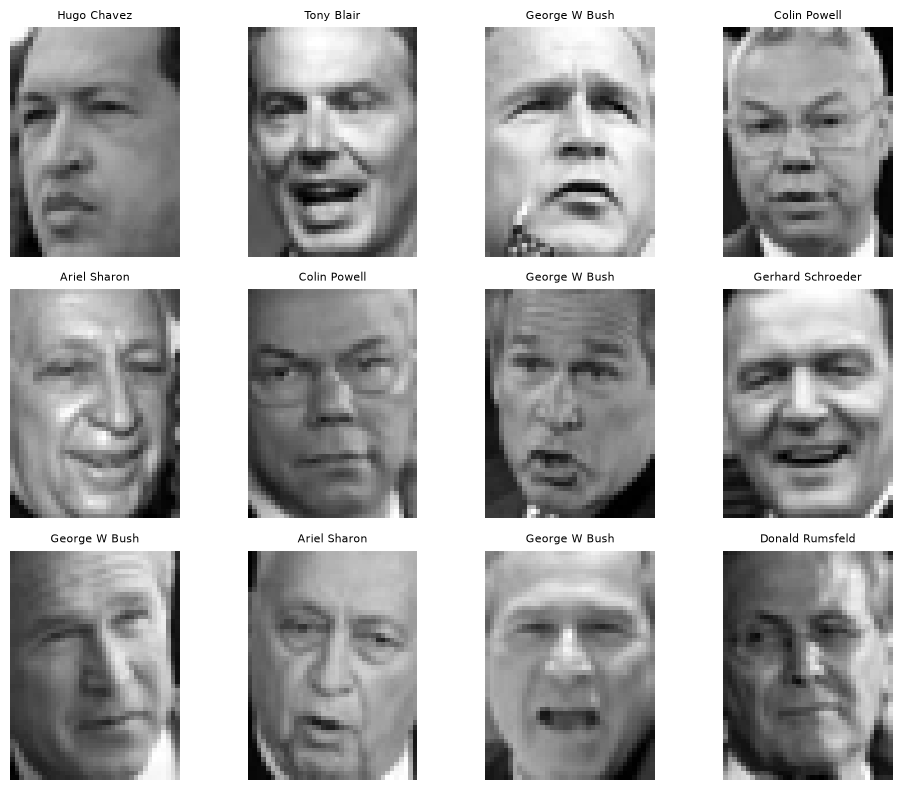

In [5]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(10,8)
)

for ax, image, label in zip(
    axes.ravel(),
    lfw.images,
    lfw.target
):
    ax.imshow(image, cmap='gray')
    ax.set_title(
        lfw.target_names[label],
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()

plt.show()

# Prepare Features and Labels

In [6]:
X = lfw.data

y = lfw.target

# Split Dataset

Split the dataset into training and testing sets using an 80:20 ratio.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Extraction using Principal Component Analysis (PCA)

Facial images contain thousands of pixel values, resulting in high-dimensional data.

Principal Component Analysis (PCA) is used to reduce the dimensionality while preserving the most important facial features. These reduced features are commonly referred to as **Eigenfaces**.

Benefits of PCA:
- Reduces computational complexity
- Removes redundant information
- Improves classifier performance

In [8]:
pca = PCA(
    n_components=150,
    whiten=True,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Verify Transformed Feature Dimensions

Check the dimensions of the dataset after applying PCA.

In [9]:
print("Original Training Shape :", X_train.shape)
print("Reduced Training Shape :", X_train_pca.shape)

print("Original Testing Shape :", X_test.shape)
print("Reduced Testing Shape :", X_test_pca.shape)

Original Training Shape : (1030, 1850)
Reduced Training Shape : (1030, 150)
Original Testing Shape : (258, 1850)
Reduced Testing Shape : (258, 150)


# Visualize Eigenfaces

Display the first twelve principal components (Eigenfaces) learned by PCA.

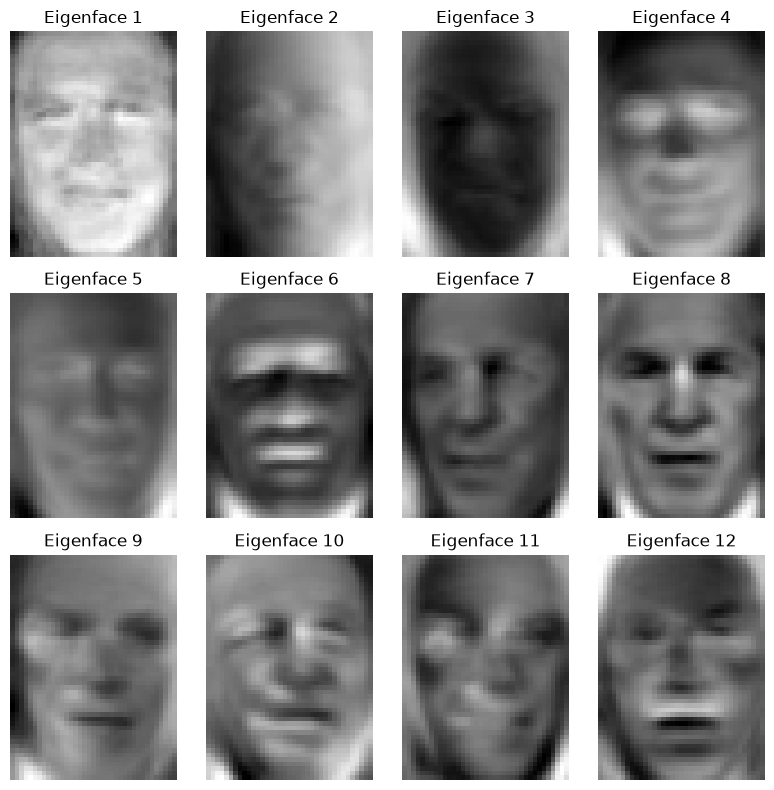

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        pca.components_[i].reshape(lfw.images.shape[1:]),
        cmap='gray'
    )
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Train the Support Vector Machine (SVM)

Train an SVM classifier using the PCA-transformed facial features.

The Radial Basis Function (RBF) kernel is used for nonlinear classification.

In [11]:
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_pca, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


# Predict Face Classes

Use the trained SVM model to predict the identities of the test images.

In [12]:
y_pred = svm_model.predict(X_test_pca)

# Evaluate Model Accuracy

Measure the overall accuracy of the face recognition model on the test dataset.

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 84.88%


# Classification Report

Generate precision, recall, F1-score, and support for each person in the dataset.

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=lfw.target_names
    )
)

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.64      0.78        11
     Colin Powell       0.63      0.96      0.76        47
  Donald Rumsfeld       0.83      0.68      0.75        22
    George W Bush       0.94      0.91      0.92       119
Gerhard Schroeder       0.89      0.89      0.89        19
      Hugo Chavez       1.00      0.46      0.63        13
       Tony Blair       0.95      0.78      0.86        27

         accuracy                           0.85       258
        macro avg       0.89      0.76      0.80       258
     weighted avg       0.88      0.85      0.85       258



# Confusion Matrix

Visualize the classification results using a confusion matrix.

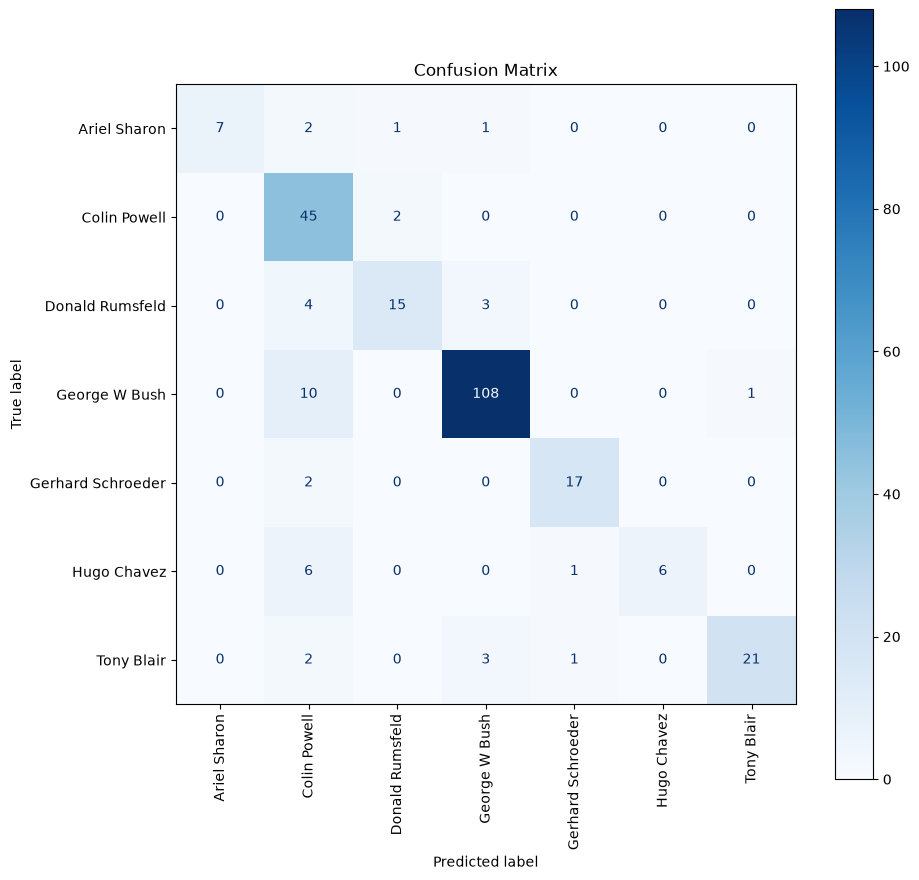

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lfw.target_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

# Save the Trained Models

Save both the trained PCA model and the SVM classifier for future face recognition tasks.

In [16]:
joblib.dump(pca, "../models/pca_model.pkl")
joblib.dump(svm_model, "../models/svm_face_recognition.pkl")

print("Models saved successfully.")

Models saved successfully.


# Visualize Predictions

Display a few test images along with their predicted and actual identities.

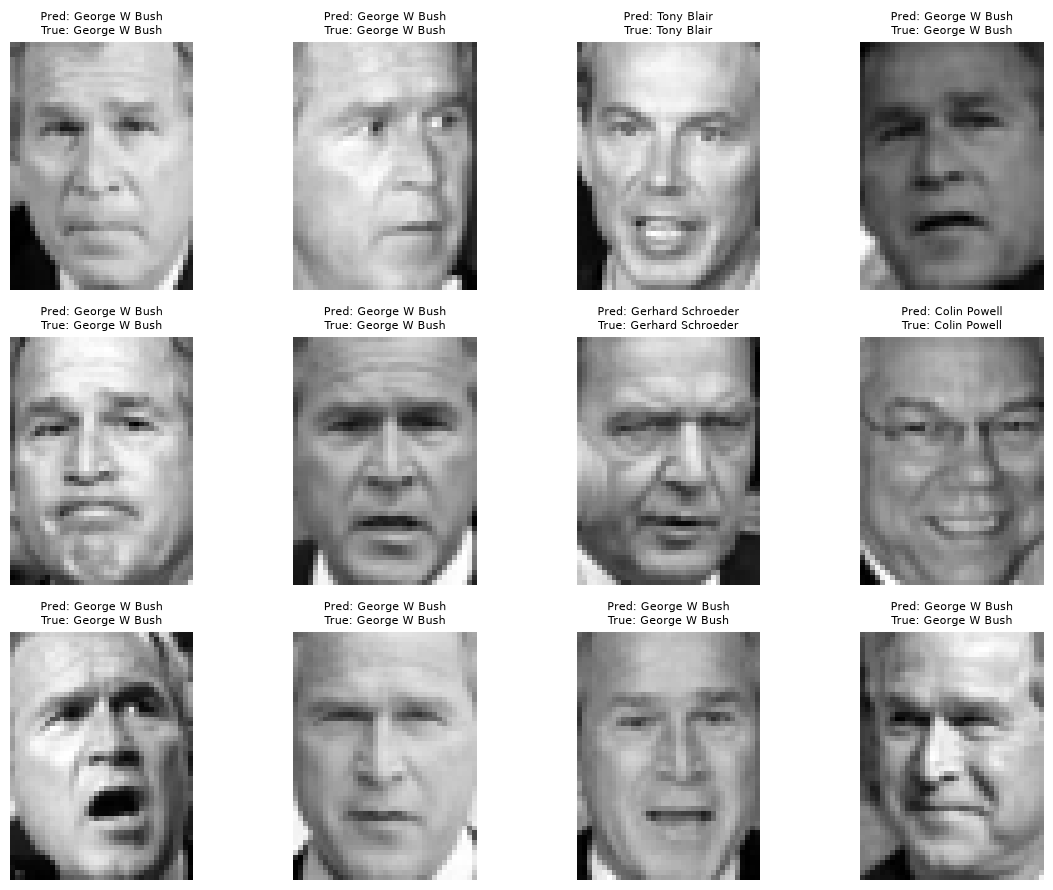

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, image, prediction, actual in zip(
    axes.ravel(),
    X_test,
    y_pred,
    y_test
):
    ax.imshow(
        image.reshape(lfw.images.shape[1:]),
        cmap='gray'
    )

    ax.set_title(
        f"Pred: {lfw.target_names[prediction]}\nTrue: {lfw.target_names[actual]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Predict a Single Face

Use the trained model to predict the identity of a single test image.

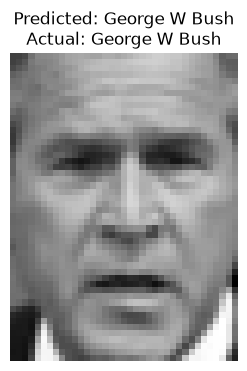

In [18]:
sample = 5

prediction = svm_model.predict(
    X_test_pca[sample].reshape(1, -1)
)

plt.figure(figsize=(4,4))
plt.imshow(
    X_test[sample].reshape(lfw.images.shape[1:]),
    cmap="gray"
)

plt.title(
    f"Predicted: {lfw.target_names[prediction[0]]}\nActual: {lfw.target_names[y_test[sample]]}"
)

plt.axis("off")
plt.show()

# Conclusion

In this project, a face recognition system was developed using the Labeled Faces in the Wild (LFW) dataset.

Principal Component Analysis (PCA) was applied to reduce the dimensionality of facial images and extract significant facial features (Eigenfaces). A Support Vector Machine (SVM) classifier was then trained on these transformed features to recognize different individuals.

The model was evaluated using accuracy, a classification report, and a confusion matrix. Finally, the trained models were saved for future inference.

This project demonstrates a complete classical machine learning pipeline for face recognition.